In [1]:
import os

In [6]:
from typing import List,TypedDict
import time
from langchain_community.document_loaders.pdf import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
docs=PyPDFLoader("docs/ML Book.pdf").load()

In [5]:
len(docs)

564

In [7]:
splitter=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150)

In [8]:
chunks=splitter.split_documents(docs)

In [9]:
for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [10]:
len(chunks)

1652

In [11]:
embeddings=OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore=FAISS.from_documents(chunks,embeddings)

In [12]:
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={"k":4})

In [13]:
llm=ChatOpenAI(model="gpt-4.1",temperature=0)

In [14]:
vectorstore.save_local("vectorstore")

In [15]:
class State(TypedDict):
    question:str
    docs:List[Document]
    answer:str

In [16]:
def retrieve(state:State):
    q=state["question"]
    return {"docs":retriever.invoke(q)}

In [17]:
retriever.invoke("What is the difference between supervised and unsupervised learning?")

[Document(id='34f8d27c-b4d8-4882-987b-1da0bc7d280d', metadata={'producer': 'Antenna House PDF Output Library 6.2.609 (Linux64)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2017-03-10T21:55:34+00:00', 'author': 'Aurélien Géron', 'moddate': '2017-07-29T21:43:02+08:00', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow', 'trapped': '/False', 'source': 'docs/ML Book.pdf', 'total_pages': 564, 'page': 31, 'page_label': '10'}, page_content='Unsupervised learning\nIn unsu\npervised learning, as you might guess, the training data is unlabeled\n(Figure 1-7). The system tries to learn without a teacher.\nFigure 1-7. An unlabeled training set for unsupervised learning\nHere are some of the most im portan\nt unsupervised learning algorithms (we will\ncover dimensionality reduction in Chapter 8):\n• Clustering\n— k-Means\n— Hierarchical Cluster Analysis (HCA)\n— Expectation Maximization\n• Visualization and dimensionali

In [18]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state:State):
    context="\n\n".join([d.page_content for d in state["docs"]])
    out=(prompt|llm).invoke({"question":state["question"],"context":context})
    return {"answer":out.content}

In [19]:
g=StateGraph(State)
g.add_node("generate",generate)
g.add_node("retrieve",retrieve)
g.add_edge(START,"retrieve")
g.add_edge("retrieve","generate")
g.add_edge("generate",END)

app=g.compile()

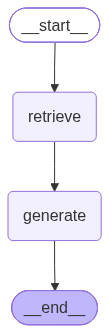

In [20]:
app

In [21]:
res=app.invoke({"question":"what is transformers, and why aren't we using them in genai much than hardcore ml and deep learning?"})

In [27]:
print(res['docs'][0].page_content)
print("$"*50)
print(res['docs'][1].page_content)
print("$"*50)
print(res['docs'][2].page_content)
print("$"*50)
print(res['docs'][3].page_content)

All transformers also have a convenience method called fit_transform() 
Prepare the Data for Machine Learning Algorithms | 61
 D o w n l o a d   f r o m   f i n e l y b o o k   w w w . f i n e l y b o o k . c o m
$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
we restrict our creativity to biologically plausible systems.1
ANNs are at the very core of Deep Learning. They are versatile, powerful, and scala‐
ble, making them ideal to tackle large and highly complex Machine Learning tasks,
such as classifying billions of images (e.g., Google Images), powering speech recogni‐
tion services (e.g., Apple’s Siri), recommending the best videos to watch to hundreds
of millions of users every day (e.g., Y ouTube), or learning to beat the world champion
at the game of Go by examining millions of past games and then playing against itself
(DeepMind’s AlphaGo).
In this chapter, we will introduce artificial neural networks, starting with a quick tour
of the very first ANN architectures. Then we wi

In [26]:
print(res['answer'])

Based on the context provided, "transformers" refer to objects or methods in machine learning libraries (such as scikit-learn) that are used to transform data, for example, by scaling features or preparing data for machine learning algorithms. All transformers have a convenience method called fit_transform(), which is used to fit the transformer to the data and then transform the data in one step.

The context does not mention the use of "transformers" as a neural network architecture (such as those used in modern NLP like BERT or GPT), but rather as data preprocessing tools.

Regarding why transformers (as described in the context) aren't used as much in "genai" (generative AI) compared to "hardcore ML and deep learning," the context does not provide information on this topic. It mainly discusses the use of artificial neural networks (ANNs), deep learning, and data transformation tools in machine learning workflows.

Therefore, based on the context, transformers are primarily used for